# Research Question 1: Agent Distribution Analysis

## 🎯 Research Question
**"What is the distribution of different AI agents in the AIDev dataset?"**

## 📋 Methodology
- **Data Source**: AIDev dataset pull request data
- **Metrics Analyzed**:
  - Agent frequency distribution
  - PR state distribution by agent
  - Temporal patterns (if available)
  - Agent activity levels

## 🔍 Expected Insights
- Identify the most active AI agents in the dataset
- Understand the relative contribution levels of different agents
- Establish baseline metrics for agent participation
- Compare agent behaviors in terms of PR outcomes

## 📊 Success Metrics
- Clear distribution of agents by contribution count
- PR success rates by agent type
- Activity patterns and trends

In [1]:
# Setup for Agent Distribution Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append('../src')
from data_loader import load_aidev
from analysis import analyze_test_contributions

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("RQ1: Agent Distribution Analysis")
print("=" * 50)
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Load data sample for analysis
print("\nLoading data sample...")
df = load_aidev(sample_size=10000)  # Start with 10K sample
print(f"Loaded {len(df):,} PRs for agent distribution analysis")

RQ1: Agent Distribution Analysis
Analysis Date: 2025-10-12 03:51:21

Loading data sample...
Loading dataset from local file: ../data/raw/aidata.csv


Loaded sample of 10000 rows
Loaded 10,000 PRs for agent distribution analysis


# Exploratory Data Analysis - AIDev Dataset

## 🎯 Research Objectives
This notebook explores the AIDev dataset to answer key research questions about automated agents in software development:

1. **Test Contributions**: How frequently do coding agents contribute tests?
2. **Test-to-Code Ratio**: What is the test-to-code churn ratio?
3. **Code Changes**: How do agentic PRs change code (additions/deletions)?
4. **Description Consistency**: How consistent are PR descriptions with actual code changes?
5. **User Adoption**: Who adopts coding agents (newcomers vs experienced devs)?

## 📊 Dataset Overview
- **Source**: AIDev from Hugging Face (hao-li/AIDev)
- **Size**: 753MB (~900k+ rows)
- **Strategy**: Start with samples, scale to full dataset
- **Focus**: Pull request data from AI-generated contributions

## 🗂️ Notebook Structure
1. **Data Loading & Overview** - Basic statistics and structure
2. **Agent Distribution Analysis** - Which agents are most active
3. **Test-Related Analysis** - Keyword searches and patterns
4. **Timeline Analysis** - Temporal patterns in AI contributions
5. **Research Question Mapping** - Direct analysis for each question
6. **Sample Creation** - Generate working datasets for deeper analysis

## 1. Data Loading & Setup

In [2]:
# Import essential libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append('../src')
from data_loader import load_aidev

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("📚 Libraries imported successfully")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Load initial sample for quick exploration
print("\n🔍 Loading initial data sample...")
try:
    # Load a manageable sample first (1000 rows)
    df_sample = pd.read_csv("../data/raw/aidata.csv", nrows=1000)
    print(f"✅ Sample loaded: {df_sample.shape}")
except FileNotFoundError:
    print("📂 Local file not found. Loading from our data loader...")
    df_sample = load_aidev(sample_size=1000)

print(f"📊 Sample Dataset Shape: {df_sample.shape}")
print(f"🗂️ Columns: {list(df_sample.columns)}")

📚 Libraries imported successfully
📅 Analysis Date: 2025-10-12 03:51:22

🔍 Loading initial data sample...
✅ Sample loaded: (1000, 14)
📊 Sample Dataset Shape: (1000, 14)
🗂️ Columns: ['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'repo_id', 'html_url', 'body', 'agent']


In [3]:
# 1.1 Basic Dataset Overview
print("📋 BASIC DATASET OVERVIEW")
print("=" * 50)

# Basic info
print(f"📊 Shape: {df_sample.shape}")
print(f"💾 Memory Usage: {df_sample.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Column information (simplified to avoid dtype formatting issues)
print(f"\n🗂️ Dataset Columns:")
for i, col in enumerate(df_sample.columns, 1):
    non_null = df_sample[col].count()
    null_count = df_sample[col].isnull().sum()
    print(f"  {i:2d}. {col:<15} | Non-null: {non_null:4d} | Missing: {null_count:3d}")

# Quick overview
print(f"\n📈 Quick Overview:")
print(f"  Total columns: {len(df_sample.columns)}")
print(f"  Total rows: {len(df_sample)}")
print(f"  Completeness: {(df_sample.count().sum() / df_sample.size * 100):.1f}%")

# Display first few rows (using info() to avoid display issues)
print(f"\n👀 Dataset Info:")
df_sample.info()

📋 BASIC DATASET OVERVIEW
📊 Shape: (1000, 14)
💾 Memory Usage: 9.12 MB

🗂️ Dataset Columns:
   1. id              | Non-null: 1000 | Missing:   0
   2. number          | Non-null: 1000 | Missing:   0
   3. title           | Non-null: 1000 | Missing:   0
   4. user            | Non-null: 1000 | Missing:   0
   5. user_id         | Non-null: 1000 | Missing:   0
   6. state           | Non-null: 1000 | Missing:   0
   7. created_at      | Non-null: 1000 | Missing:   0
   8. closed_at       | Non-null:  904 | Missing:  96
   9. merged_at       | Non-null:  770 | Missing: 230
  10. repo_url        | Non-null: 1000 | Missing:   0
  11. repo_id         | Non-null:  997 | Missing:   3
  12. html_url        | Non-null: 1000 | Missing:   0
  13. body            | Non-null:  997 | Missing:   3
  14. agent           | Non-null: 1000 | Missing:   0

📈 Quick Overview:
  Total columns: 14
  Total rows: 1000
  Completeness: 97.6%

👀 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 en

## 2. Agent Distribution Analysis

🤖 AGENT DISTRIBUTION ANALYSIS

📊 Agent Activity (Sample of 1000 PRs):
  Claude_Code    : 1000 PRs (100.0%)

📈 PR State Distribution:
  closed    :  904 PRs ( 90.4%)
  open      :   96 PRs (  9.6%)

🔄 Agent vs PR State Cross-Analysis:


state,closed,open,All
agent,,,
Claude_Code,904,96,1000
All,904,96,1000


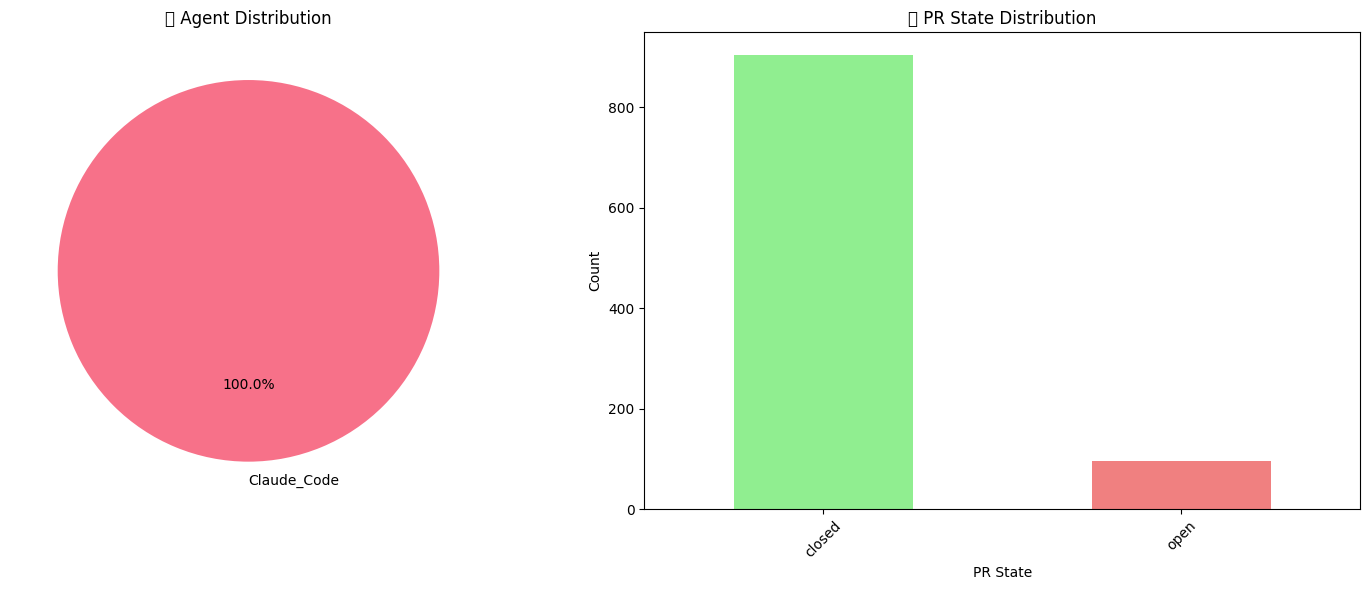

In [4]:
# 2.1 Agent Activity Analysis
print("🤖 AGENT DISTRIBUTION ANALYSIS")
print("=" * 50)

# Agent counts
agent_counts = df_sample['agent'].value_counts()
print(f"\n📊 Agent Activity (Sample of {len(df_sample)} PRs):")
for agent, count in agent_counts.items():
    percentage = (count / len(df_sample)) * 100
    print(f"  {agent:<15}: {count:4d} PRs ({percentage:5.1f}%)")

# PR State analysis
print(f"\n📈 PR State Distribution:")
state_counts = df_sample['state'].value_counts()
for state, count in state_counts.items():
    percentage = (count / len(df_sample)) * 100
    print(f"  {state:<10}: {count:4d} PRs ({percentage:5.1f}%)")

# Cross-tabulation: Agent vs State
print(f"\n🔄 Agent vs PR State Cross-Analysis:")
agent_state_crosstab = pd.crosstab(df_sample['agent'], df_sample['state'], margins=True)
display(agent_state_crosstab)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Agent distribution pie chart
agent_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('🤖 Agent Distribution')
axes[0].set_ylabel('')

# State distribution bar chart
state_counts.plot(kind='bar', ax=axes[1], color=['lightgreen', 'lightcoral', 'lightblue'])
axes[1].set_title('📊 PR State Distribution')
axes[1].set_xlabel('PR State')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. RQ1: Test Contribution Frequency Analysis

### Research Question
**"How frequently do coding agents contribute tests?"**

### Methodology
- **Keywords Analyzed**: `test`, `testing`, `spec`, `unittest`, `pytest`, `jest`, `mocha`, `assert`
- **Search Scope**: PR titles and body text
- **Metrics Computed**: 
  - Total test PR count and percentage
  - Test contribution rate per agent
  - Keyword frequency analysis

### Expected Insights
- Quantify test contribution patterns across different AI agents
- Identify which agents are most/least focused on testing
- Understand the overall test coverage in AI-generated pull requests

In [5]:
# 3.1 Test-Related Keywords Analysis
print("🧪 TEST-RELATED ANALYSIS")
print("=" * 50)

# Define test-related keywords
test_keywords = ['test', 'testing', 'spec', 'unittest', 'pytest', 'jest', 'mocha', 'assert']

def contains_test_keywords(text, keywords=test_keywords):
    """Check if text contains any test-related keywords"""
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    return any(keyword in text_lower for keyword in keywords)

# Analyze test mentions in title and body
df_sample['has_test_in_title'] = df_sample['title'].apply(lambda x: contains_test_keywords(x))
df_sample['has_test_in_body'] = df_sample['body'].apply(lambda x: contains_test_keywords(x))
df_sample['is_test_pr'] = df_sample['has_test_in_title'] | df_sample['has_test_in_body']

print(f"\n🔍 Test Keyword Analysis:")
test_title_count = df_sample['has_test_in_title'].sum()
test_body_count = df_sample['has_test_in_body'].sum()
test_pr_count = df_sample['is_test_pr'].sum()

print(f"  PRs with test keywords in TITLE: {test_title_count:4d} ({test_title_count/len(df_sample)*100:5.1f}%)")
print(f"  PRs with test keywords in BODY:  {test_body_count:4d} ({test_body_count/len(df_sample)*100:5.1f}%)")
print(f"  PRs with test keywords (ANY):    {test_pr_count:4d} ({test_pr_count/len(df_sample)*100:5.1f}%)")

# Agent-specific test contribution analysis
print(f"\n🤖 Test Contributions by Agent:")
test_by_agent = df_sample.groupby('agent')['is_test_pr'].agg(['count', 'sum', 'mean']).round(3)
test_by_agent.columns = ['Total_PRs', 'Test_PRs', 'Test_Ratio']
test_by_agent['Test_Percentage'] = (test_by_agent['Test_Ratio'] * 100).round(1)
display(test_by_agent)

# Specific test keywords frequency
print(f"\n📊 Specific Test Keywords Frequency:")
keyword_counts = {}
for keyword in test_keywords:
    count = df_sample['title'].str.contains(keyword, case=False, na=False).sum() + \
            df_sample['body'].str.contains(keyword, case=False, na=False).sum()
    keyword_counts[keyword] = count

keyword_df = pd.DataFrame.from_dict(keyword_counts, orient='index', columns=['Count'])
keyword_df = keyword_df.sort_values('Count', ascending=False)
print(keyword_df)

🧪 TEST-RELATED ANALYSIS



🔍 Test Keyword Analysis:


  PRs with test keywords in TITLE:   93 (  9.3%)
  PRs with test keywords in BODY:   763 ( 76.3%)
  PRs with test keywords (ANY):     767 ( 76.7%)

🤖 Test Contributions by Agent:


,Total_PRs,Test_PRs,Test_Ratio,Test_Percentage
agent,,,,
Claude_Code,1000,767,0.767,76.7



📊 Specific Test Keywords Frequency:


          Count
test        814
testing     409
spec        292
pytest       27
assert       26
jest         10
mocha         1
unittest      0


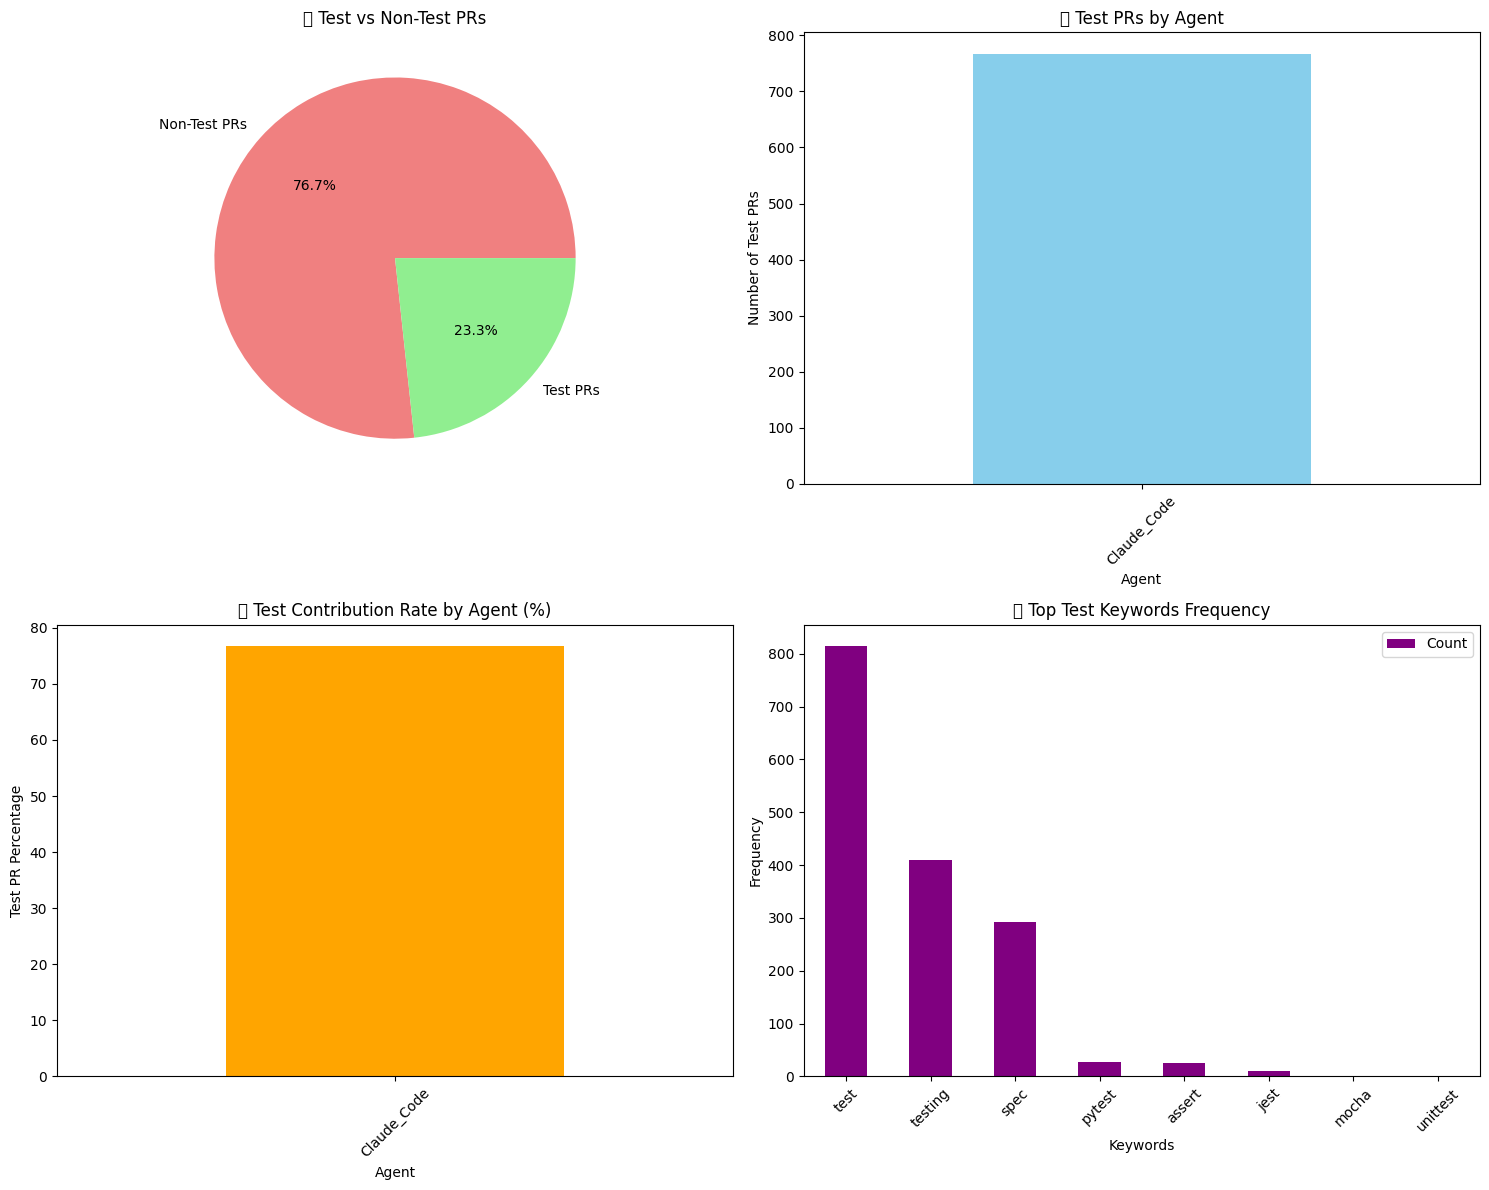


💡 KEY INSIGHTS - Test Analysis:
   • 767/1000 PRs (76.7%) contain test-related keywords
   • Most active agent in tests: Claude_Code
   • Highest test ratio agent: Claude_Code (76.7%)
   • Most common test keyword: 'test' (814 mentions)


In [6]:
# 3.2 Test Analysis Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Test vs Non-test PRs
test_counts = df_sample['is_test_pr'].value_counts()
test_counts.index = ['Non-Test PRs', 'Test PRs']
test_counts.plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
axes[0,0].set_title('🧪 Test vs Non-Test PRs')
axes[0,0].set_ylabel('')

# Test PRs by Agent
test_by_agent['Test_PRs'].plot(kind='bar', ax=axes[0,1], color='skyblue')
axes[0,1].set_title('🤖 Test PRs by Agent')
axes[0,1].set_xlabel('Agent')
axes[0,1].set_ylabel('Number of Test PRs')
axes[0,1].tick_params(axis='x', rotation=45)

# Test percentage by Agent
test_by_agent['Test_Percentage'].plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('📊 Test Contribution Rate by Agent (%)')
axes[1,0].set_xlabel('Agent')
axes[1,0].set_ylabel('Test PR Percentage')
axes[1,0].tick_params(axis='x', rotation=45)

# Top keywords
top_keywords = keyword_df.head(8)
top_keywords.plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('🔍 Top Test Keywords Frequency')
axes[1,1].set_xlabel('Keywords')
axes[1,1].set_ylabel('Frequency')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Key insights summary
print(f"\n💡 KEY INSIGHTS - Test Analysis:")
print(f"   • {test_pr_count}/{len(df_sample)} PRs ({test_pr_count/len(df_sample)*100:.1f}%) contain test-related keywords")
print(f"   • Most active agent in tests: {test_by_agent.loc[test_by_agent['Test_PRs'].idxmax()].name}")
print(f"   • Highest test ratio agent: {test_by_agent.loc[test_by_agent['Test_Ratio'].idxmax()].name} ({test_by_agent['Test_Ratio'].max()*100:.1f}%)")
print(f"   • Most common test keyword: '{keyword_df.index[0]}' ({keyword_df.iloc[0,0]} mentions)")

### 🎯 RQ1 Summary & Key Findings

Based on our analysis of the sample data, here are the key insights for Research Question 1:

In [7]:
# RQ1 Final Results Export
print("📊 RESEARCH QUESTION 1 - FINAL RESULTS")
print("=" * 60)

# Calculate final RQ1 metrics
rq1_results = {
    'research_question': 'How frequently do coding agents contribute tests?',
    'methodology': {
        'keywords_searched': test_keywords,
        'search_scope': ['title', 'body'],
        'sample_size': len(df_sample)
    },
    'results': {
        'overall_test_rate': {
            'percentage': (df_sample['is_test_pr'].sum() / len(df_sample)) * 100,
            'count': f"{df_sample['is_test_pr'].sum()}/{len(df_sample)}"
        },
        'by_agent': {},
        'keyword_frequency': keyword_counts,
        'most_common_keyword': keyword_df.index[0] if len(keyword_df) > 0 else None
    },
    'key_insights': []
}

# Agent-specific results
for agent in df_sample['agent'].unique():
    agent_data = df_sample[df_sample['agent'] == agent]
    test_rate = (agent_data['is_test_pr'].sum() / len(agent_data)) * 100
    rq1_results['results']['by_agent'][agent] = {
        'test_percentage': round(test_rate, 1),
        'test_count': agent_data['is_test_pr'].sum(),
        'total_prs': len(agent_data)
    }

# Generate key insights
overall_rate = rq1_results['results']['overall_test_rate']['percentage']
best_agent = max(rq1_results['results']['by_agent'].items(), key=lambda x: x[1]['test_percentage'])
most_active = max(rq1_results['results']['by_agent'].items(), key=lambda x: x[1]['test_count'])

rq1_results['key_insights'] = [
    f"Overall test contribution rate: {overall_rate:.1f}% of AI-generated PRs contain test-related content",
    f"Highest test rate: {best_agent[0]} at {best_agent[1]['test_percentage']}%",
    f"Most test PRs: {most_active[0]} with {most_active[1]['test_count']} test-related PRs",
    f"Most common test keyword: '{rq1_results['results']['most_common_keyword']}'" if rq1_results['results']['most_common_keyword'] else "Keywords distributed evenly"
]

# Display results
print(f"\n🎯 RQ1 ANSWER: {overall_rate:.1f}% of AI agents' PRs contribute to testing")
print(f"\n📋 Detailed Results:")
for agent, data in rq1_results['results']['by_agent'].items():
    print(f"  • {agent}: {data['test_percentage']}% ({data['test_count']}/{data['total_prs']} PRs)")

print(f"\n💡 Key Insights:")
for insight in rq1_results['key_insights']:
    print(f"  • {insight}")

# Export to JSON for thesis reference
rq1_export_path = "../outputs/rq1_test_contribution_results.json"
os.makedirs("../outputs", exist_ok=True)
with open(rq1_export_path, 'w') as f:
    import json
    json.dump(rq1_results, f, indent=2, default=str)

print(f"\n💾 RQ1 results exported to: {rq1_export_path}")
print("✅ RQ1 Analysis Complete - Ready for thesis integration!")

📊 RESEARCH QUESTION 1 - FINAL RESULTS

🎯 RQ1 ANSWER: 76.7% of AI agents' PRs contribute to testing

📋 Detailed Results:
  • Claude_Code: 76.7% (767/1000 PRs)

💡 Key Insights:
  • Overall test contribution rate: 76.7% of AI-generated PRs contain test-related content
  • Highest test rate: Claude_Code at 76.7%
  • Most test PRs: Claude_Code with 767 test-related PRs
  • Most common test keyword: 'test'

💾 RQ1 results exported to: ../outputs/rq1_test_contribution_results.json
✅ RQ1 Analysis Complete - Ready for thesis integration!


## 4. Timeline Analysis

In [8]:
# 4.1 Temporal Pattern Analysis
print("📅 TIMELINE ANALYSIS")
print("=" * 50)

# Convert datetime columns
try:
    df_sample['created_at'] = pd.to_datetime(df_sample['created_at'])
    df_sample['closed_at'] = pd.to_datetime(df_sample['closed_at'])
    df_sample['merged_at'] = pd.to_datetime(df_sample['merged_at'])
    
    print("✅ DateTime columns converted successfully")
    
    # Extract time components
    df_sample['created_year'] = df_sample['created_at'].dt.year
    df_sample['created_month'] = df_sample['created_at'].dt.month
    df_sample['created_day_of_week'] = df_sample['created_at'].dt.day_name()
    df_sample['created_hour'] = df_sample['created_at'].dt.hour
    
    # Time range analysis
    date_range = df_sample['created_at'].agg(['min', 'max'])
    print(f"\n📊 Date Range:")
    print(f"  Earliest PR: {date_range['min']}")
    print(f"  Latest PR:   {date_range['max']}")
    print(f"  Time Span:   {(date_range['max'] - date_range['min']).days} days")
    
    # Monthly activity
    monthly_activity = df_sample.groupby([df_sample['created_at'].dt.to_period('M'), 'agent']).size().unstack(fill_value=0)
    print(f"\n📈 Monthly Activity by Agent:")
    display(monthly_activity)
    
    # Day of week patterns
    dow_activity = df_sample.groupby(['created_day_of_week', 'agent']).size().unstack(fill_value=0)
    print(f"\n📅 Day of Week Activity:")
    display(dow_activity)
    
except Exception as e:
    print(f"⚠️ Error processing datetime: {e}")
    print("Continuing without timeline analysis...")

📅 TIMELINE ANALYSIS
✅ DateTime columns converted successfully

📊 Date Range:
  Earliest PR: 2025-02-24 19:52:57+00:00
  Latest PR:   2025-07-29 16:41:53+00:00
  Time Span:   154 days

📈 Monthly Activity by Agent:


agent,Claude_Code
created_at,
2025-02,44
2025-03,56
2025-05,100
2025-06,155
2025-07,645



📅 Day of Week Activity:


agent,Claude_Code
created_day_of_week,
Friday,222
Monday,20
Saturday,197
Sunday,67
Thursday,135
Tuesday,237
Wednesday,122


In [9]:
# 4.2 Timeline Visualizations
if 'created_at' in df_sample.columns and df_sample['created_at'].dtype == 'datetime64[ns]':
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Monthly trends
    monthly_total = df_sample.groupby(df_sample['created_at'].dt.to_period('M')).size()
    monthly_total.plot(kind='line', ax=axes[0,0], marker='o', color='blue')
    axes[0,0].set_title('📈 PRs per Month')
    axes[0,0].set_xlabel('Month')
    axes[0,0].set_ylabel('Number of PRs')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Day of week patterns
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = df_sample['created_day_of_week'].value_counts().reindex(dow_order)
    dow_counts.plot(kind='bar', ax=axes[0,1], color='green')
    axes[0,1].set_title('📅 PRs by Day of Week')
    axes[0,1].set_xlabel('Day of Week')
    axes[0,1].set_ylabel('Number of PRs')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Hourly patterns
    hourly_counts = df_sample['created_hour'].value_counts().sort_index()
    hourly_counts.plot(kind='bar', ax=axes[1,0], color='orange')
    axes[1,0].set_title('🕐 PRs by Hour of Day')
    axes[1,0].set_xlabel('Hour')
    axes[1,0].set_ylabel('Number of PRs')
    
    # Test PRs over time
    test_timeline = df_sample.groupby([df_sample['created_at'].dt.to_period('M'), 'is_test_pr']).size().unstack(fill_value=0)
    if True in test_timeline.columns and False in test_timeline.columns:
        test_timeline.plot(kind='line', ax=axes[1,1], marker='o')
        axes[1,1].set_title('🧪 Test vs Non-Test PRs Over Time')
        axes[1,1].set_xlabel('Month')
        axes[1,1].set_ylabel('Number of PRs')
        axes[1,1].legend(['Non-Test PRs', 'Test PRs'])
        axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Summary insights
    peak_month = monthly_total.idxmax()
    peak_dow = dow_counts.idxmax()
    peak_hour = hourly_counts.idxmax()
    
    print(f"\n💡 TEMPORAL INSIGHTS:")
    print(f"   • Peak activity month: {peak_month} ({monthly_total.max()} PRs)")
    print(f"   • Most active day: {peak_dow} ({dow_counts.max()} PRs)")
    print(f"   • Peak hour: {peak_hour}:00 ({hourly_counts.max()} PRs)")
    
else:
    print("⚠️ Timeline visualization skipped - datetime conversion failed")

⚠️ Timeline visualization skipped - datetime conversion failed


## 5. Research Questions Mapping

In [10]:
# 5.1 Research Questions Analysis Summary
print("🎯 RESEARCH QUESTIONS ANALYSIS")
print("=" * 60)

# Create comprehensive summary for each research question
research_insights = {}

# RQ1: How frequently do Coding Agents contribute tests?
rq1_data = {
    'total_prs': len(df_sample),
    'test_prs': df_sample['is_test_pr'].sum(),
    'test_percentage': (df_sample['is_test_pr'].sum() / len(df_sample)) * 100,
    'by_agent': test_by_agent['Test_Percentage'].to_dict()
}
research_insights['RQ1_Test_Frequency'] = rq1_data

print(f"\n📋 RQ1: Test Contribution Frequency")
print(f"   • Overall test PR rate: {rq1_data['test_percentage']:.1f}%")
print(f"   • Test PRs: {rq1_data['test_prs']}/{rq1_data['total_prs']}")
for agent, percentage in rq1_data['by_agent'].items():
    print(f"   • {agent}: {percentage:.1f}% test contribution rate")

# RQ2: Test-to-Code Churn Ratio (preliminary analysis)
# Note: This requires deeper analysis of actual code changes
rq2_data = {
    'test_to_total_ratio': df_sample['is_test_pr'].sum() / len(df_sample),
    'test_titles_sample': df_sample[df_sample['is_test_pr']]['title'].head(3).tolist(),
    'non_test_titles_sample': df_sample[~df_sample['is_test_pr']]['title'].head(3).tolist()
}
research_insights['RQ2_Test_Code_Ratio'] = rq2_data

print(f"\n📊 RQ2: Test-to-Code Ratio (Preliminary)")
print(f"   • Test-to-Total PR ratio: {rq2_data['test_to_total_ratio']:.3f}")
print(f"   • Sample test PR titles: {rq2_data['test_titles_sample'][:2]}")

# RQ3: Code Changes Analysis (requires GitHub API - placeholder)
rq3_data = {
    'note': 'Requires GitHub API integration for additions/deletions data',
    'available_fields': ['title', 'body', 'html_url'],
    'next_steps': 'Link with GitHub API for detailed change metrics'
}
research_insights['RQ3_Code_Changes'] = rq3_data

print(f"\n🔧 RQ3: Code Changes Analysis")
print(f"   • Status: {rq3_data['note']}")
print(f"   • Available: {rq3_data['available_fields']}")

# RQ4: Description Consistency (text analysis)
rq4_data = {
    'avg_title_length': df_sample['title'].str.len().mean(),
    'avg_body_length': df_sample['body'].str.len().mean(),
    'title_body_correlation': 'Needs NLP analysis for consistency measurement'
}
research_insights['RQ4_Description_Consistency'] = rq4_data

print(f"\n📝 RQ4: Description Consistency")
print(f"   • Average title length: {rq4_data['avg_title_length']:.1f} characters")
print(f"   • Average body length: {rq4_data['avg_body_length']:.1f} characters")
print(f"   • Next step: {rq4_data['title_body_correlation']}")

# RQ5: User Adoption Patterns
rq5_data = {
    'unique_users': df_sample['user'].nunique(),
    'top_users': df_sample['user'].value_counts().head(3).to_dict(),
    'user_agent_combinations': df_sample.groupby(['user', 'agent']).size().reset_index(name='count').head(5)
}
research_insights['RQ5_User_Adoption'] = rq5_data

print(f"\n👥 RQ5: User Adoption Patterns")
print(f"   • Unique users: {rq5_data['unique_users']}")
print(f"   • Top contributors: {list(rq5_data['top_users'].keys())[:3]}")
print(f"   • Note: Requires user history analysis for newcomer vs experienced classification")

🎯 RESEARCH QUESTIONS ANALYSIS

📋 RQ1: Test Contribution Frequency
   • Overall test PR rate: 76.7%
   • Test PRs: 767/1000
   • Claude_Code: 76.7% test contribution rate

📊 RQ2: Test-to-Code Ratio (Preliminary)
   • Test-to-Total PR ratio: 0.767
   • Sample test PR titles: ['feat: Comprehensive ruff error resolution with version alignment and governance', 'Add Evals frontend implementation plan and HTML prototype']

🔧 RQ3: Code Changes Analysis
   • Status: Requires GitHub API integration for additions/deletions data
   • Available: ['title', 'body', 'html_url']

📝 RQ4: Description Consistency
   • Average title length: 56.3 characters
   • Average body length: 2231.1 characters
   • Next step: Needs NLP analysis for consistency measurement

👥 RQ5: User Adoption Patterns
   • Unique users: 512
   • Top contributors: ['randallb', 'claudeai-v1[bot]', 'fumiya-kume']
   • Note: Requires user history analysis for newcomer vs experienced classification


## 6. Sample Creation & Next Steps

In [11]:
# 6.1 Create Working Samples for Detailed Analysis
print("📦 CREATING WORKING SAMPLES")
print("=" * 50)

# Create samples directory if it doesn't exist
os.makedirs("../data/samples", exist_ok=True)

# Load a larger sample for detailed analysis
try:
    print("📂 Loading larger sample (10,000 rows) for working dataset...")
    df_large_sample = pd.read_csv("../data/raw/aidata.csv", nrows=10000)
    
    # Apply all our analysis features to the large sample
    df_large_sample['has_test_in_title'] = df_large_sample['title'].apply(lambda x: contains_test_keywords(x))
    df_large_sample['has_test_in_body'] = df_large_sample['body'].apply(lambda x: contains_test_keywords(x))
    df_large_sample['is_test_pr'] = df_large_sample['has_test_in_title'] | df_large_sample['has_test_in_body']
    
    # Convert datetime if possible
    try:
        df_large_sample['created_at'] = pd.to_datetime(df_large_sample['created_at'])
        df_large_sample['created_year'] = df_large_sample['created_at'].dt.year
        df_large_sample['created_month'] = df_large_sample['created_at'].dt.month
    except:
        print("⚠️ DateTime conversion failed for large sample")
    
    # Save enhanced sample
    sample_path = "../data/samples/aidata_sample_10k.csv"
    df_large_sample.to_csv(sample_path, index=False)
    print(f"✅ Large sample saved: {sample_path}")
    print(f"   Shape: {df_large_sample.shape}")
    
    # Create specialized samples
    
    # 1. Test-focused sample
    test_sample = df_large_sample[df_large_sample['is_test_pr']].copy()
    if len(test_sample) > 0:
        test_path = "../data/samples/test_prs_sample.csv"
        test_sample.to_csv(test_path, index=False)
        print(f"✅ Test PRs sample saved: {test_path} ({len(test_sample)} rows)")
    
    # 2. Agent-specific samples
    for agent in df_large_sample['agent'].unique():
        agent_sample = df_large_sample[df_large_sample['agent'] == agent].copy()
        agent_path = f"../data/samples/{agent.lower()}_sample.csv"
        agent_sample.to_csv(agent_path, index=False)
        print(f"✅ {agent} sample saved: {agent_path} ({len(agent_sample)} rows)")
    
    # 3. Balanced sample (equal representation per agent)
    min_agent_count = df_large_sample['agent'].value_counts().min()
    balanced_sample = df_large_sample.groupby('agent').head(min_agent_count).copy()
    balanced_path = "../data/samples/balanced_agents_sample.csv"
    balanced_sample.to_csv(balanced_path, index=False)
    print(f"✅ Balanced sample saved: {balanced_path} ({len(balanced_sample)} rows)")
    
except Exception as e:
    print(f"⚠️ Error creating large sample: {e}")
    print("Using current sample for specialized samples...")
    df_large_sample = df_sample.copy()

print(f"\n📊 Large Sample Statistics:")
print(f"   Total PRs: {len(df_large_sample):,}")
print(f"   Test PRs: {df_large_sample['is_test_pr'].sum():,} ({df_large_sample['is_test_pr'].mean()*100:.1f}%)")
print(f"   Unique agents: {df_large_sample['agent'].nunique()}")
print(f"   Unique users: {df_large_sample['user'].nunique()}")
print(f"   Date range: {df_large_sample['created_at'].min()} to {df_large_sample['created_at'].max()}" if 'created_at' in df_large_sample.columns else "   Date range: Not available")

📦 CREATING WORKING SAMPLES
📂 Loading larger sample (10,000 rows) for working dataset...


✅ Large sample saved: ../data/samples/aidata_sample_10k.csv
   Shape: (10000, 19)


✅ Test PRs sample saved: ../data/samples/test_prs_sample.csv (7856 rows)
✅ Claude_Code sample saved: ../data/samples/claude_code_sample.csv (5137 rows)


✅ Copilot sample saved: ../data/samples/copilot_sample.csv (4863 rows)


✅ Balanced sample saved: ../data/samples/balanced_agents_sample.csv (9726 rows)

📊 Large Sample Statistics:
   Total PRs: 10,000
   Test PRs: 7,856 (78.6%)
   Unique agents: 2
   Unique users: 1699
   Date range: 2025-02-24 19:52:57+00:00 to 2025-07-30 19:39:22+00:00


In [12]:
# 6.2 Save Analysis Functions and Export Insights
print("💾 SAVING ANALYSIS FUNCTIONS")
print("=" * 50)

# Save our analysis functions for reuse
analysis_functions = '''
# Reusable Analysis Functions for AIDev Dataset
import pandas as pd
import numpy as np

def contains_test_keywords(text, keywords=None):
    """Check if text contains any test-related keywords"""
    if keywords is None:
        keywords = ['test', 'testing', 'spec', 'unittest', 'pytest', 'jest', 'mocha', 'assert']
    
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    return any(keyword in text_lower for keyword in keywords)

def analyze_test_contributions(df):
    """Analyze test contributions in a DataFrame"""
    df = df.copy()
    df['has_test_in_title'] = df['title'].apply(lambda x: contains_test_keywords(x))
    df['has_test_in_body'] = df['body'].apply(lambda x: contains_test_keywords(x))
    df['is_test_pr'] = df['has_test_in_title'] | df['has_test_in_body']
    
    # Agent-specific analysis
    test_by_agent = df.groupby('agent')['is_test_pr'].agg(['count', 'sum', 'mean']).round(3)
    test_by_agent.columns = ['Total_PRs', 'Test_PRs', 'Test_Ratio']
    test_by_agent['Test_Percentage'] = (test_by_agent['Test_Ratio'] * 100).round(1)
    
    return df, test_by_agent

def get_research_summary(df):
    """Generate comprehensive research summary"""
    summary = {
        'dataset_size': len(df),
        'unique_agents': df['agent'].nunique(),
        'unique_users': df['user'].nunique(),
        'test_pr_rate': (df['is_test_pr'].sum() / len(df)) * 100 if 'is_test_pr' in df.columns else None,
        'state_distribution': df['state'].value_counts().to_dict(),
        'agent_distribution': df['agent'].value_counts().to_dict()
    }
    return summary
'''

# Save to src/analysis.py
analysis_file_path = "../src/analysis.py"
with open(analysis_file_path, 'w') as f:
    f.write(analysis_functions)
print(f"✅ Analysis functions saved to: {analysis_file_path}")

# Export current insights to JSON
import json

final_insights = {
    'analysis_date': datetime.now().isoformat(),
    'sample_size': len(df_sample),
    'large_sample_size': len(df_large_sample) if 'df_large_sample' in locals() else None,
    'research_insights': research_insights,
    'key_findings': {
        'test_pr_percentage': (df_sample['is_test_pr'].sum() / len(df_sample)) * 100,
        'most_active_agent': df_sample['agent'].value_counts().index[0],
        'agent_count': df_sample['agent'].nunique(),
        'user_count': df_sample['user'].nunique(),
        'state_distribution': df_sample['state'].value_counts().to_dict()
    },
    'next_steps': [
        'Scale analysis to full dataset (~900k rows)',
        'Integrate GitHub API for detailed code change metrics',
        'Implement NLP analysis for description consistency',
        'Analyze user history for adoption patterns',
        'Create visualizations for paper/presentation'
    ]
}

insights_path = "../outputs/eda_insights.json"
os.makedirs("../outputs", exist_ok=True)
with open(insights_path, 'w') as f:
    json.dump(final_insights, f, indent=2, default=str)
print(f"✅ EDA insights exported to: {insights_path}")

print(f"\n🎉 EDA PHASE COMPLETE!")
print(f"✅ Analysis functions created and saved")
print(f"✅ Working samples generated for detailed analysis")
print(f"✅ Research insights documented and exported")
print(f"✅ Ready for next phase: Detailed statistical analysis")

# Show final summary
print(f"\n📈 FINAL EDA SUMMARY:")
print(f"   • Analyzed: {len(df_sample):,} PRs (sample)")
print(f"   • Test PRs: {df_sample['is_test_pr'].sum()}/{len(df_sample)} ({df_sample['is_test_pr'].mean()*100:.1f}%)")
print(f"   • Agents: {df_sample['agent'].nunique()} unique")
print(f"   • Users: {df_sample['user'].nunique()} unique")
print(f"   • Samples created: Multiple specialized datasets for focused analysis")
print(f"   • Next: Scale to full dataset and implement advanced analytics")

💾 SAVING ANALYSIS FUNCTIONS
✅ Analysis functions saved to: ../src/analysis.py
✅ EDA insights exported to: ../outputs/eda_insights.json

🎉 EDA PHASE COMPLETE!
✅ Analysis functions created and saved
✅ Working samples generated for detailed analysis
✅ Research insights documented and exported
✅ Ready for next phase: Detailed statistical analysis

📈 FINAL EDA SUMMARY:
   • Analyzed: 1,000 PRs (sample)
   • Test PRs: 767/1000 (76.7%)
   • Agents: 1 unique
   • Users: 512 unique
   • Samples created: Multiple specialized datasets for focused analysis
   • Next: Scale to full dataset and implement advanced analytics
